In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from pathlib import Path

In [3]:
CSV_PATH   = "gen8ou-1825/gen8ou_1825_usage_timeseries.csv"
FOCAL_MONTH = "2022-10"   # swap this to any month in the dataset
CUTOFF     = 5.0          # minimum usage % for the bar chart
 
df = pd.read_csv(CSV_PATH)
 
# usage is a decimal (e.g. 0.312); convert to percent
df["usage_pct"] = df["usage"] * 100
 
# ── per-pokemon summary stats across ALL months ──────────────────────────────
summary = (
    df.groupby("pokemon")["usage_pct"]
    .agg(mean_percent="mean", sd_percent="std")
    .fillna(0)
    .reset_index()
)
SAVE_DIR = Path("gen8ou_graphs_Lab_6") 
SAVE_DIR.mkdir(parents=True, exist_ok=True) 

In [4]:
focal = (
    df[df["month"] == FOCAL_MONTH][["pokemon", "usage_pct"]]
    .rename(columns={"usage_pct": "focal_percent"})
)
 
plot_df = focal.merge(summary, on="pokemon", how="left").fillna(0)

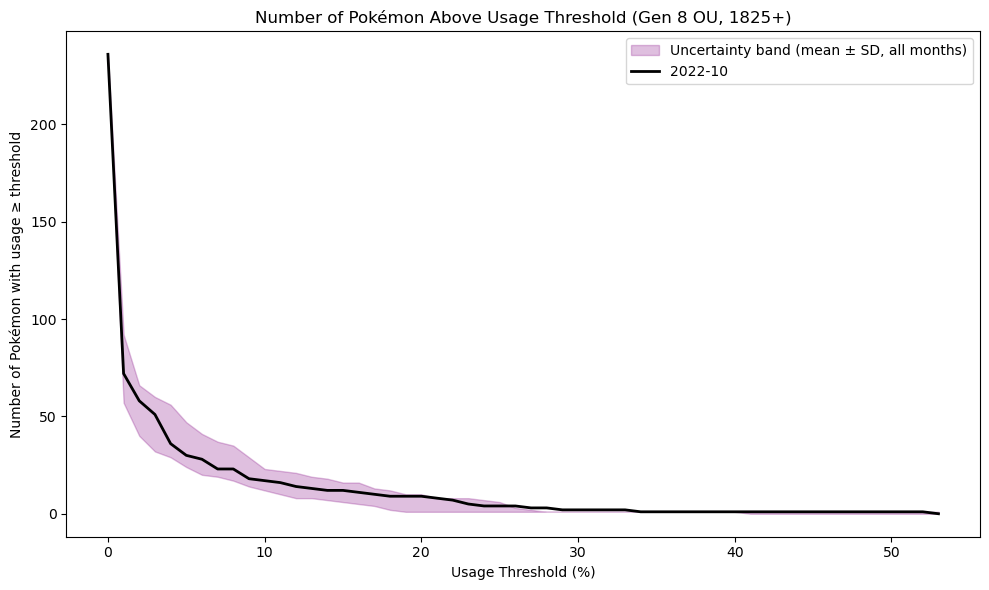

In [5]:
thresholds   = np.arange(0, plot_df["focal_percent"].max() + 1, 1)
counts_focal = np.array([(plot_df["focal_percent"] >= t).sum() for t in thresholds])
counts_low   = np.array([((plot_df["mean_percent"] - plot_df["sd_percent"]).clip(lower=0) >= t).sum() for t in thresholds])
counts_high  = np.array([((plot_df["mean_percent"] + plot_df["sd_percent"]) >= t).sum() for t in thresholds])
 
plt.figure(figsize=(10, 6))
plt.fill_between(
    thresholds,
    counts_low,
    counts_high,
    color="purple",
    alpha=0.25,
    label="Uncertainty band (mean ± SD, all months)"
)
plt.plot(
    thresholds,
    counts_focal,
    color="black",
    linewidth=2,
    label=f"{FOCAL_MONTH}"
)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU, 1825+)")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / f"Initial_Line+Unc_Shade{FOCAL_MONTH}.png", dpi=150)
plt.show()

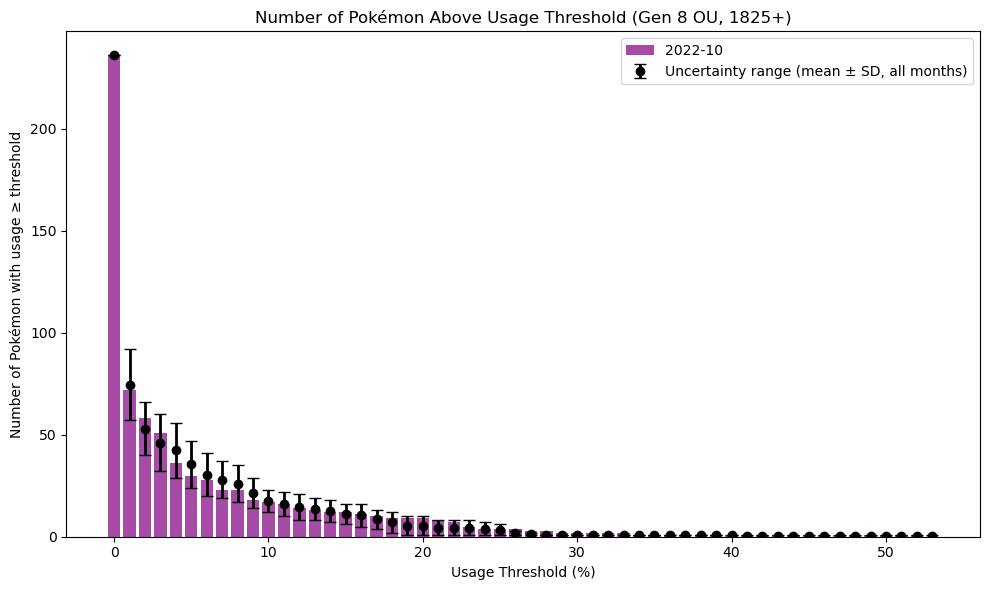

In [6]:
thresholds   = np.arange(0, plot_df["focal_percent"].max() + 1, 1)
counts_focal = np.array([(plot_df["focal_percent"] >= t).sum() for t in thresholds])
counts_low   = np.array([((plot_df["mean_percent"] - plot_df["sd_percent"]).clip(lower=0) >= t).sum() for t in thresholds])
counts_high  = np.array([((plot_df["mean_percent"] + plot_df["sd_percent"]) >= t).sum() for t in thresholds])

counts_mean = (counts_low + counts_high) / 2
counts_err  = (counts_high - counts_low) / 2

plt.figure(figsize=(10, 6))

plt.bar(
    thresholds,
    counts_focal,
    width=0.8,
    color="purple",
    alpha=0.7,
    label=f"{FOCAL_MONTH}"
)

plt.errorbar(
    thresholds,
    counts_mean,
    yerr=counts_err,
    fmt="o",
    color="black",
    capsize=4,
    linewidth=2,
    label="Uncertainty range (mean ± SD, all months)"
)

plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU, 1825+)")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / f"Line-2-Bar+Unc{FOCAL_MONTH}.png", dpi=150)
plt.show()

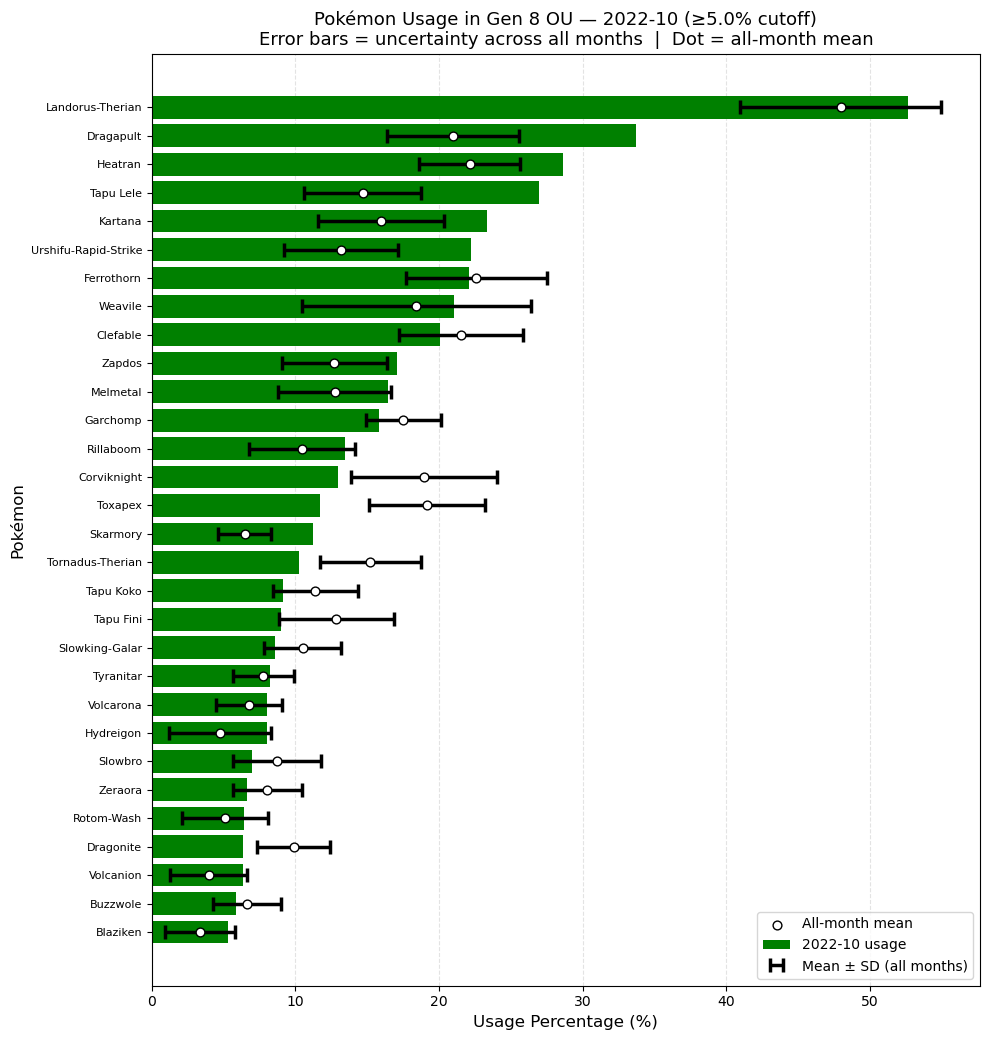

In [7]:
filtered = (
    plot_df[plot_df["focal_percent"] >= CUTOFF]
    .sort_values("focal_percent", ascending=True)
)
 
fig, ax = plt.subplots(figsize=(10, max(6, len(filtered) * 0.35)))
y = np.arange(len(filtered))
 
ax.barh(y, filtered["focal_percent"], color="green", alpha=1.0,
        label=f"{FOCAL_MONTH} usage", zorder=2)
ax.errorbar(
    filtered["mean_percent"], y,
    xerr=filtered["sd_percent"],
    fmt="none", ecolor="black", elinewidth=2.5,
    capsize=5, capthick=2.5, zorder=3,
    label="Mean ± SD (all months)"
)
ax.scatter(filtered["mean_percent"], y,
           color="white", edgecolors="black", s=40, zorder=4,
           label="All-month mean")
 
ax.set_yticks(y)
ax.set_yticklabels(filtered["pokemon"], fontsize=8)
ax.set_xlabel("Usage Percentage (%)", fontsize=12)
ax.set_ylabel("Pokémon", fontsize=12)
ax.set_title(
    f"Pokémon Usage in Gen 8 OU — {FOCAL_MONTH} (≥{CUTOFF}% cutoff)\n"
    "Error bars = uncertainty across all months  |  Dot = all-month mean",
    fontsize=13
)
ax.legend(fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"Ind_Mons_Bar+Unc{FOCAL_MONTH}.png", dpi=150)
plt.show()

Testing Median instead of mean


In [8]:
def _q25(x): return x.quantile(0.25)
def _q75(x): return x.quantile(0.75)
 
med_summary = (
    df.groupby("pokemon")["usage_pct"]
    .agg(med_percent="median", med_iqr_low=_q25, med_iqr_high=_q75)
    .reset_index()
)
 
med_focal = (
    df[df["month"] == FOCAL_MONTH][["pokemon", "usage_pct"]]
    .rename(columns={"usage_pct": "med_focal_percent"})
)
 
med_plot_df = med_focal.merge(med_summary, on="pokemon", how="left").fillna(0)

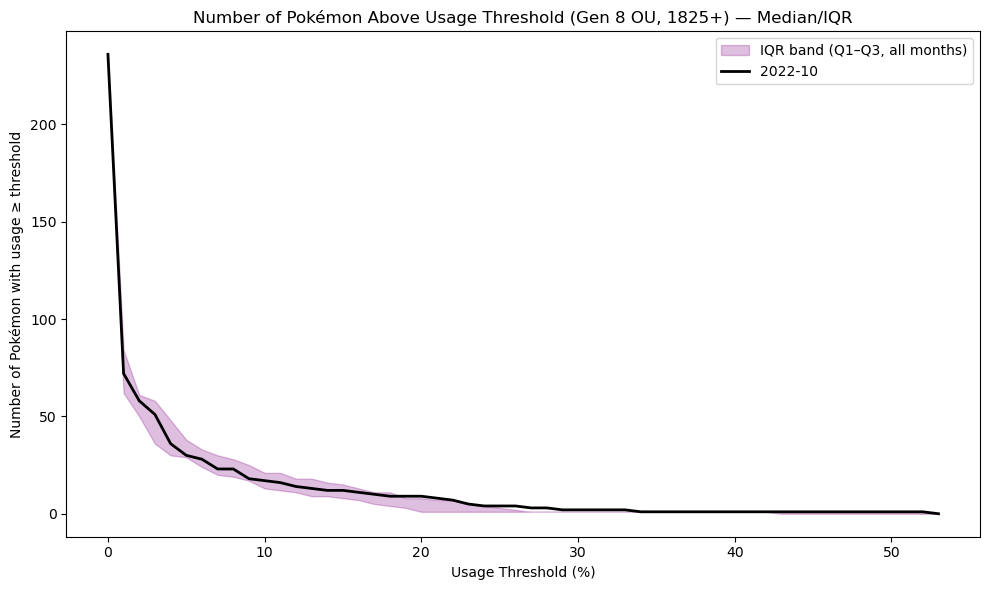

In [9]:
med_thresholds   = np.arange(0, med_plot_df["med_focal_percent"].max() + 1, 1)
med_counts_focal = np.array([(med_plot_df["med_focal_percent"] >= t).sum() for t in med_thresholds])
med_counts_low   = np.array([(med_plot_df["med_iqr_low"] >= t).sum() for t in med_thresholds])
med_counts_high  = np.array([(med_plot_df["med_iqr_high"] >= t).sum() for t in med_thresholds])
 
plt.figure(figsize=(10, 6))
plt.fill_between(
    med_thresholds,
    med_counts_low,
    med_counts_high,
    color="purple",
    alpha=0.25,
    label="IQR band (Q1–Q3, all months)"
)
plt.plot(
    med_thresholds,
    med_counts_focal,
    color="black",
    linewidth=2,
    label=f"{FOCAL_MONTH}"
)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU, 1825+) — Median/IQR")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / f"MedianLINE{FOCAL_MONTH}.png", dpi=150)
plt.show()

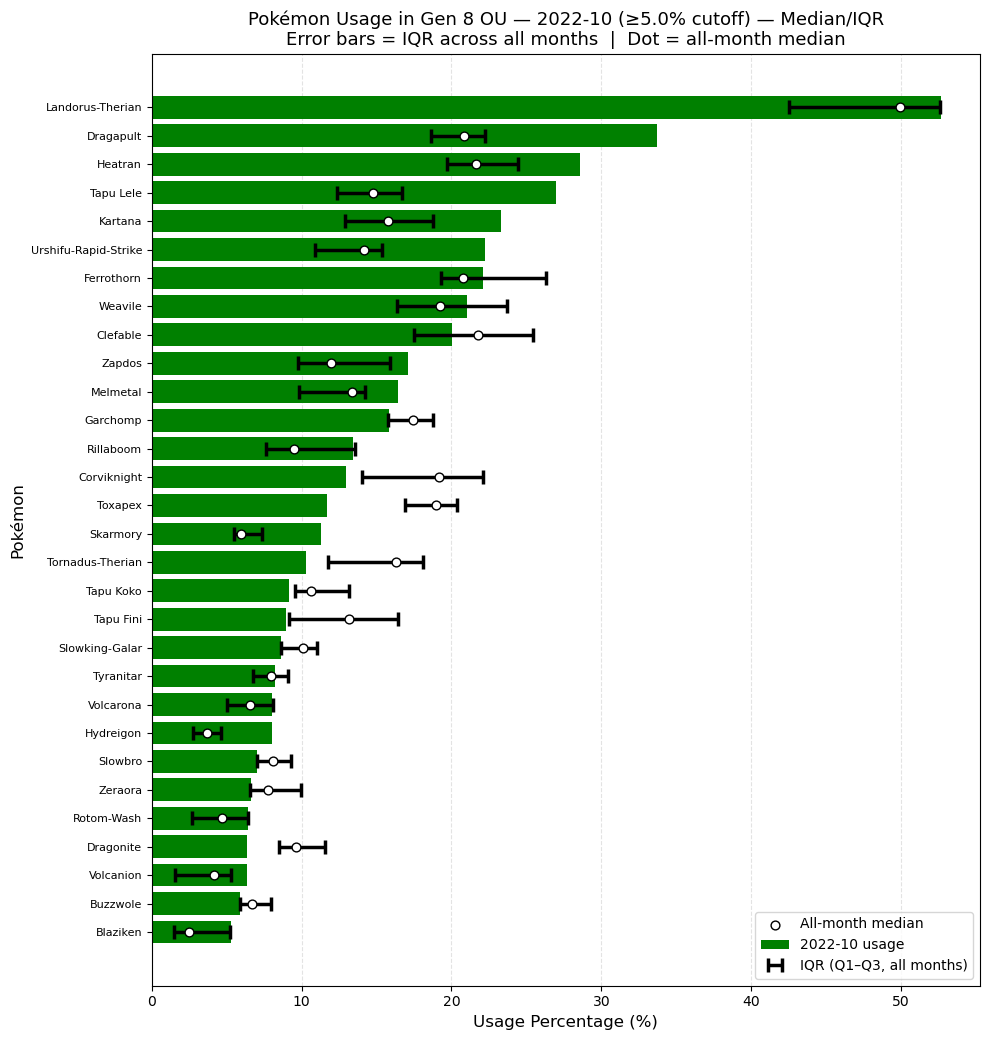

In [10]:
med_filtered = (
    med_plot_df[med_plot_df["med_focal_percent"] >= CUTOFF]
    .sort_values("med_focal_percent", ascending=True)
)
 
med_fig, med_ax = plt.subplots(figsize=(10, max(6, len(med_filtered) * 0.35)))
med_y = np.arange(len(med_filtered))
 
med_ax.barh(med_y, med_filtered["med_focal_percent"], color="green", alpha=1.0,
            label=f"{FOCAL_MONTH} usage", zorder=2)
 
med_xerr_low  = (med_filtered["med_percent"] - med_filtered["med_iqr_low"]).clip(lower=0).values
med_xerr_high = (med_filtered["med_iqr_high"] - med_filtered["med_percent"]).clip(lower=0).values
 
med_ax.errorbar(
    med_filtered["med_percent"], med_y,
    xerr=[med_xerr_low, med_xerr_high],
    fmt="none", ecolor="black", elinewidth=2.5,
    capsize=5, capthick=2.5, zorder=3,
    label="IQR (Q1–Q3, all months)"
)
med_ax.scatter(med_filtered["med_percent"], med_y,
               color="white", edgecolors="black", s=40, zorder=4,
               label="All-month median")
 
med_ax.set_yticks(med_y)
med_ax.set_yticklabels(med_filtered["pokemon"], fontsize=8)
med_ax.set_xlabel("Usage Percentage (%)", fontsize=12)
med_ax.set_ylabel("Pokémon", fontsize=12)
med_ax.set_title(
    f"Pokémon Usage in Gen 8 OU — {FOCAL_MONTH} (≥{CUTOFF}% cutoff) — Median/IQR\n"
    "Error bars = IQR across all months  |  Dot = all-month median",
    fontsize=13
)
med_ax.legend(fontsize=10)
med_ax.grid(axis="x", linestyle="--", alpha=0.35)
med_fig.tight_layout()
med_fig.savefig(SAVE_DIR / f"Median_Hor_Bar{FOCAL_MONTH}.png", dpi=150)
plt.show()

Treemap


In [11]:
tm_MIN_USAGE = 1.0  # pokemon below this median % collapsed into "Other"
 
# mean not yet computed — add it and merge with med_summary
tm_means = df.groupby("pokemon")["usage_pct"].mean().reset_index().rename(
    columns={"usage_pct": "mean_pct"}
)
tm_full = med_summary.merge(tm_means, on="pokemon", how="left")
tm_full["iqr"] = tm_full["med_iqr_high"] - tm_full["med_iqr_low"]
 
tm_named = tm_full[tm_full["med_percent"] >= tm_MIN_USAGE].copy()
tm_other = tm_full[tm_full["med_percent"] <  tm_MIN_USAGE].copy()
 
tm_other_row = pd.DataFrame([{
    "pokemon":     f"Other\n({len(tm_other)} Pokémon)",
    "med_percent": tm_other["med_percent"].sum(),
    "mean_pct":    tm_other["mean_pct"].sum(),
    "iqr":         np.nan,
}])
 
tm_df = pd.concat([tm_named, tm_other_row], ignore_index=True)

In [12]:
tm_MIN_USAGE = 1.0  # pokemon below this median % collapsed into "Other"
 
# mean not yet computed — add it and merge with med_summary
tm_means = df.groupby("pokemon")["usage_pct"].mean().reset_index().rename(
    columns={"usage_pct": "mean_pct"}
)
tm_full = med_summary.merge(tm_means, on="pokemon", how="left")
tm_full["iqr"] = tm_full["med_iqr_high"] - tm_full["med_iqr_low"]
 
tm_named = tm_full[tm_full["med_percent"] >= tm_MIN_USAGE].copy()
tm_other = tm_full[tm_full["med_percent"] <  tm_MIN_USAGE].copy()
 
tm_other_row = pd.DataFrame([{
    "pokemon":     f"Other\n({len(tm_other)} Pokémon)",
    "med_percent": tm_other["med_percent"].sum(),
    "mean_pct":    tm_other["mean_pct"].sum(),
    "iqr":         np.nan,
}])
 
tm_df = pd.concat([tm_named, tm_other_row], ignore_index=True)
tm_first_month = df["month"].min()
tm_last_month  = df["month"].max()
tm_in_first    = set(df[df["month"] == tm_first_month]["pokemon"])
tm_in_last     = set(df[df["month"] == tm_last_month]["pokemon"])
tm_legal       = tm_in_first & tm_in_last

tm_df = tm_df[
    tm_df["pokemon"].isin(tm_legal) | tm_df["pokemon"].str.startswith("Other")
].copy()


In [13]:
def _tm_layout(sizes, x, y, w, h):
    if not sizes:
        return []
    if len(sizes) == 1:
        return [(x, y, w, h)]
    rects     = []
    remaining = list(sizes)
    cx, cy, cw, ch = x, y, w, h
    while remaining:
        total = sum(remaining)
        if cw >= ch:
            row, best = [], float("inf")
            for r in remaining:
                row.append(r)
                rs    = sum(row)
                col_w = cw * rs / total if total else 0
                worst = max((col_w**2 * v) / rs**2 if rs else float("inf")
                            for v in [max(row), min(row)])
                if worst > best and len(row) > 1:
                    row.pop(); break
                best = worst
            rs    = sum(row)
            col_w = cw * rs / total if total else 0
            yo    = cy
            for r in row:
                rh = ch * r / rs if rs else 0
                rects.append((cx, yo, col_w, rh)); yo += rh
            cx += col_w; cw -= col_w; remaining = remaining[len(row):]
        else:
            row, best = [], float("inf")
            for r in remaining:
                row.append(r)
                rs    = sum(row)
                row_h = ch * rs / total if total else 0
                worst = max((row_h**2 * v) / rs**2 if rs else float("inf")
                            for v in [max(row), min(row)])
                if worst > best and len(row) > 1:
                    row.pop(); break
                best = worst
            rs    = sum(row)
            row_h = ch * rs / total if total else 0
            xo    = cx
            for r in row:
                rw = cw * r / rs if rs else 0
                rects.append((xo, cy, rw, row_h)); xo += rw
            cy += row_h; ch -= row_h; remaining = remaining[len(row):]
    return rects

In [14]:
def _tm_draw(ax, sizes_raw, labels, uncertainty_raw, title, unc_label):
    sizes       = np.array(sizes_raw, dtype=float)
    uncertainty = np.array(uncertainty_raw, dtype=float)
    other_mask  = np.isnan(uncertainty)
    valid_unc   = uncertainty[~other_mask]
    vmin, vmax  = valid_unc.min(), valid_unc.max()
    normed = np.where(
        other_mask, np.nan,
        (uncertainty - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(uncertainty)
    )
    cmap   = cm.get_cmap("YlOrRd")
    colors = ["#aaaaaa" if m else cmap(v) for v, m in zip(normed, other_mask)]
 
    order    = np.argsort(sizes)[::-1]
    sizes_s  = sizes[order].tolist()
    labels_s = [labels[i] for i in order]
    colors_s = [colors[i] for i in order]
    unc_s    = uncertainty[order]
    mask_s   = other_mask[order]
    sizes_a  = np.array(sizes_s)
 
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
    rects = _tm_layout(sizes_s, 0, 0, 100, 100)
 
    for i, ((rx, ry, rdx, rdy), label, color, unc, is_other) in enumerate(
            zip(rects, labels_s, colors_s, unc_s, mask_s)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (rx + 0.15, ry + 0.15), rdx - 0.3, rdy - 0.3,
            boxstyle="square,pad=0",
            facecolor=color, edgecolor="white", linewidth=0.8
        ))
        if rdx < 4 or rdy < 3:
            continue
        fs     = max(4.5, min(10, (rdx * rdy) ** 0.42))
        stroke = [pe.withStroke(linewidth=1.5, foreground="black")]
        ax.text(rx + rdx / 2, ry + rdy * 0.58, label,
                ha="center", va="center", fontsize=fs, fontweight="bold",
                color="white", path_effects=stroke, clip_on=True)
        if not is_other and rdx > 6 and rdy > 4:
            unc_str = f"±{unc:.1f}%" if not np.isnan(unc) else ""
            ax.text(rx + rdx / 2, ry + rdy * 0.32,
                    f"{sizes_a[i]:.1f}%  {unc_str}",
                    ha="center", va="center",
                    fontsize=max(3.5, fs - 2.5), color="white",
                    path_effects=stroke, clip_on=True)
 
    ax.set_title(title, fontsize=12, fontweight="bold", pad=6)
    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.7).set_label(unc_label, fontsize=9)

C:\Users\Anath\AppData\Local\Temp\ipykernel_9816\2439199024.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap   = cm.get_cmap("YlOrRd")


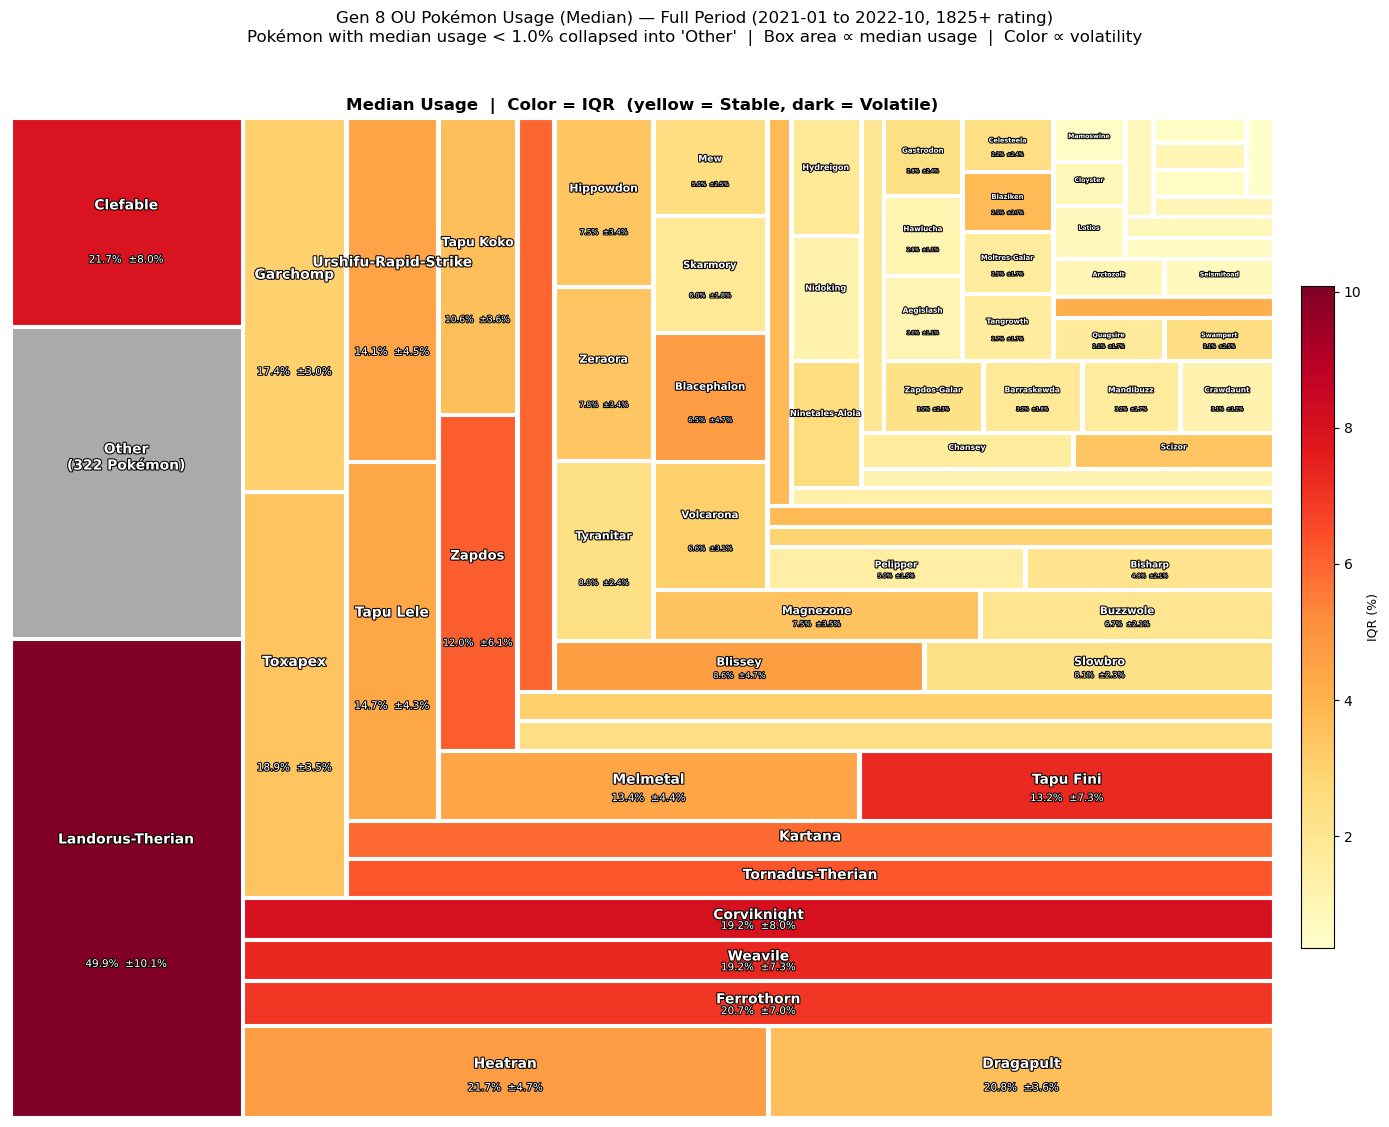

In [15]:
tm_fig1, tm_ax1 = plt.subplots(figsize=(14, 11))
_tm_draw(
    ax              = tm_ax1,
    sizes_raw       = tm_df["med_percent"].clip(lower=0.01).tolist(),
    labels          = tm_df["pokemon"].tolist(),
    uncertainty_raw = tm_df["iqr"].tolist(),
    title           = "Median Usage  |  Color = IQR  (yellow = Stable, dark = Volatile)",
    unc_label       = "IQR (%)",
)
tm_fig1.suptitle(
    "Gen 8 OU Pokémon Usage (Median) — Full Period (2021-01 to 2022-10, 1825+ rating)\n"
    f"Pokémon with median usage < {tm_MIN_USAGE}% collapsed into 'Other'  |  "
    "Box area ∝ median usage  |  Color ∝ volatility",
    fontsize=12, y=1.02
)
tm_fig1.tight_layout()
tm_fig1.savefig(SAVE_DIR / "MedianTREE.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Anath\AppData\Local\Temp\ipykernel_9816\3469132919.py:164: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Blues")


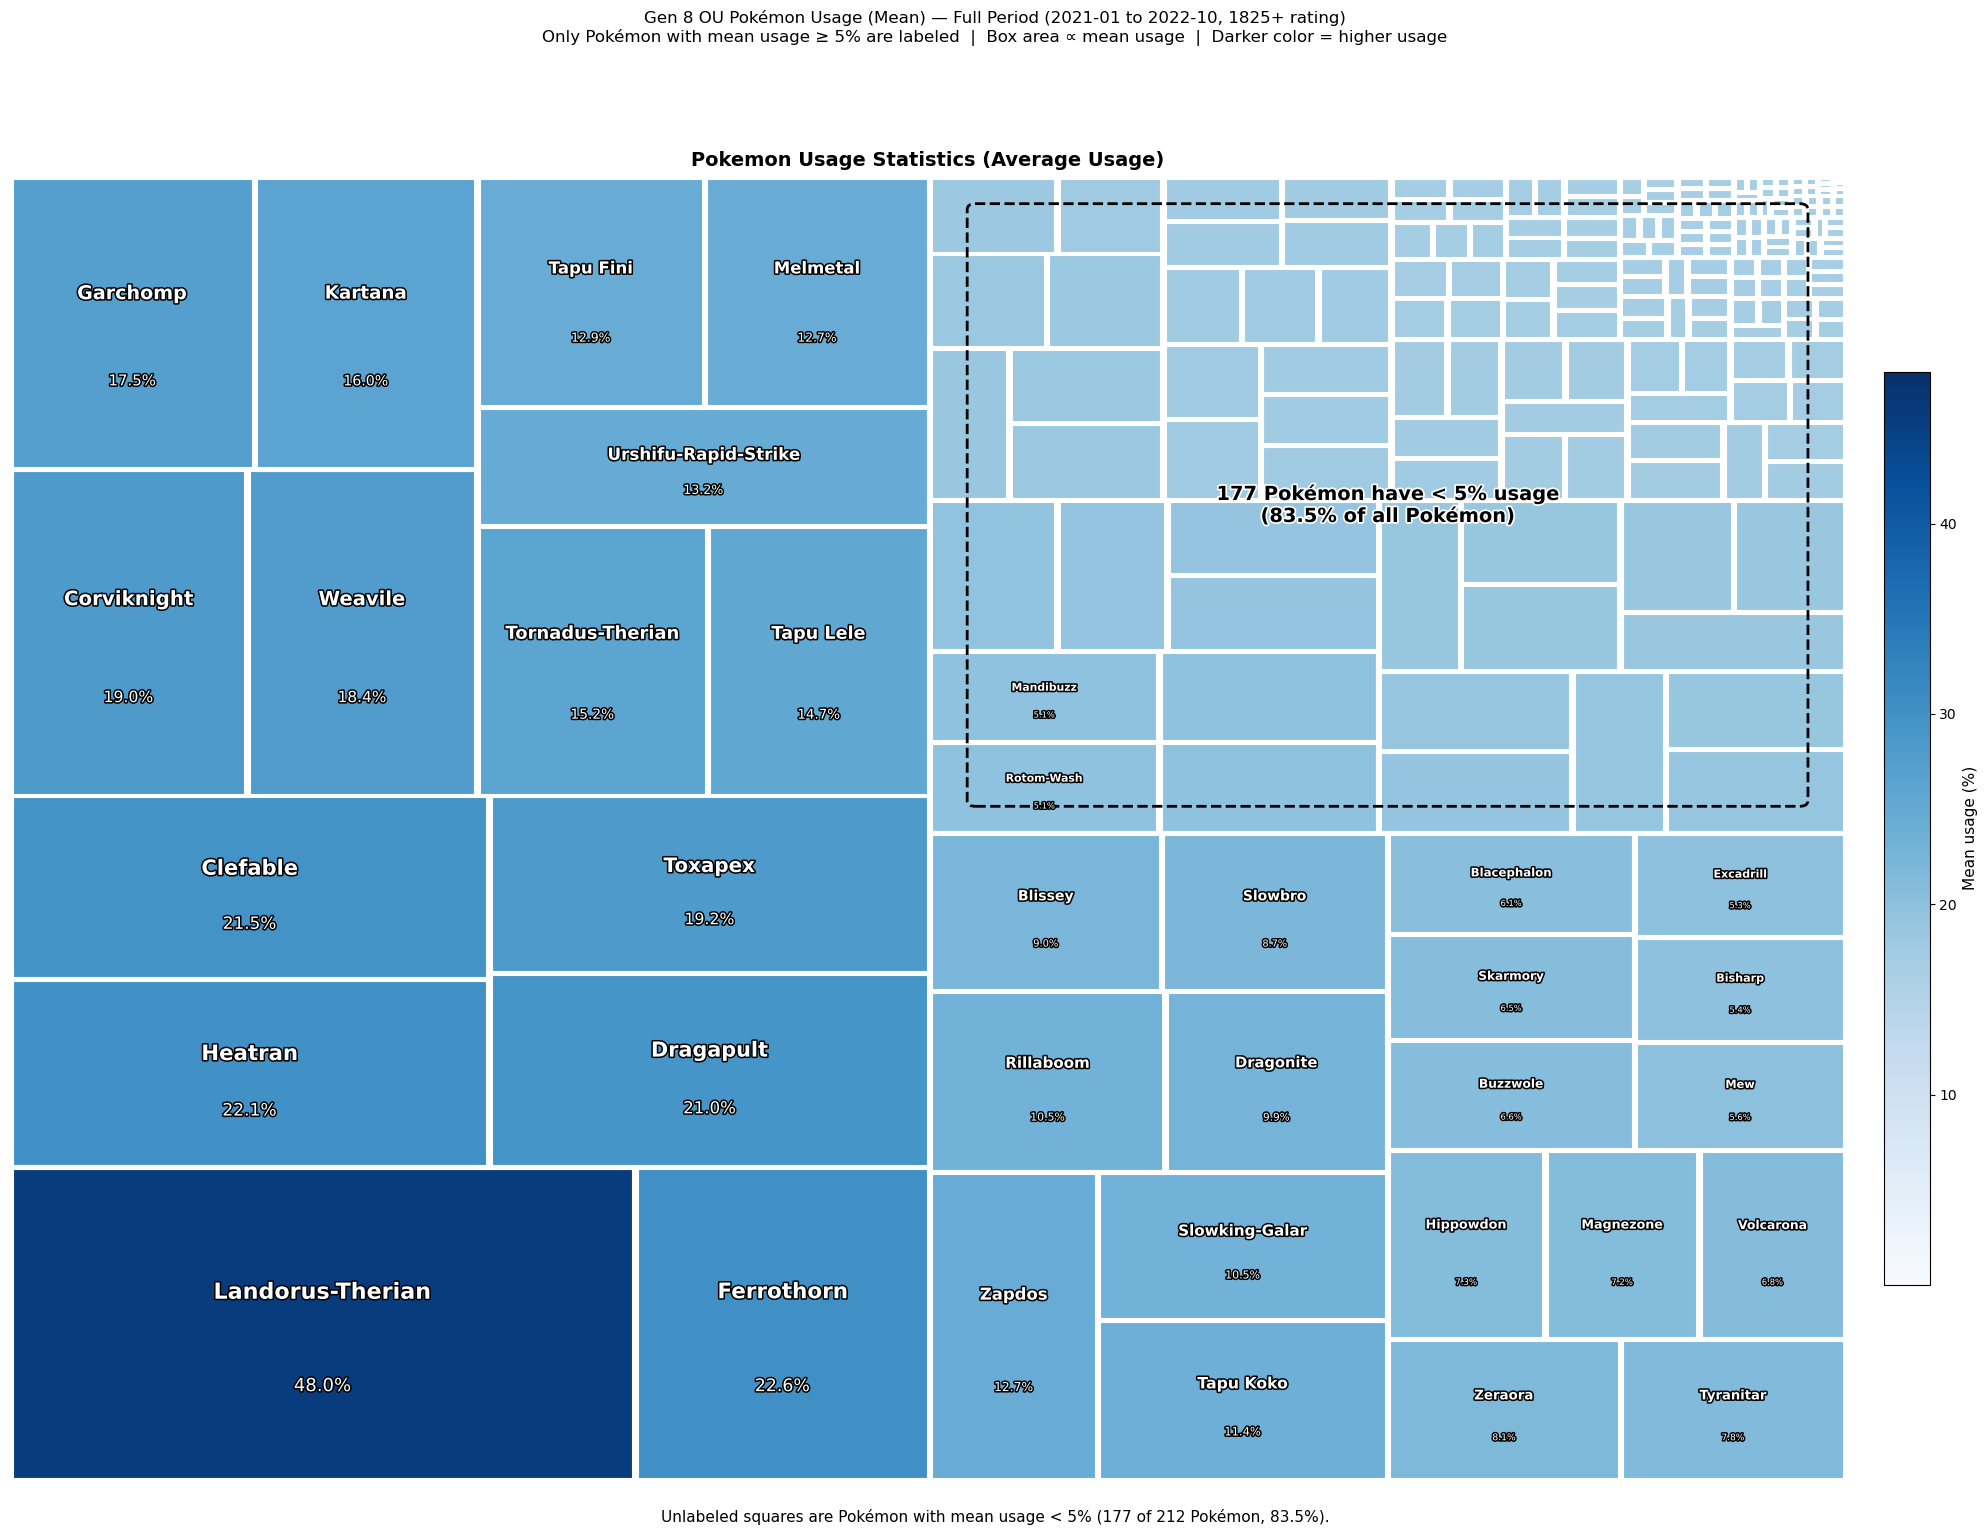

In [54]:
USAGE_LABEL_THRESHOLD = 5.0


def _tm_layout(sizes, x, y, w, h):
    sizes = [float(s) for s in sizes if s > 0]

    def recurse(vals, x, y, w, h):
        n = len(vals)
        if n == 0:
            return []
        if n == 1:
            return [(x, y, w, h)]
        if n == 2:
            s0, s1 = vals
            total = s0 + s1
            if w >= h:
                w0 = w * (s0 / total)
                return [
                    (x, y, w0, h),
                    (x + w0, y, w - w0, h),
                ]
            else:
                h0 = h * (s0 / total)
                return [
                    (x, y, w, h0),
                    (x, y + h0, w, h - h0),
                ]

        total = sum(vals)
        half = total / 2

        running = 0
        split_idx = 0
        best_diff = float("inf")
        for i, v in enumerate(vals[:-1], start=1):
            running += v
            diff = abs(half - running)
            if diff < best_diff:
                best_diff = diff
                split_idx = i

        left = vals[:split_idx]
        right = vals[split_idx:]
        left_sum = sum(left)

        if w >= h:
            w_left = w * (left_sum / total)
            return (
                recurse(left, x, y, w_left, h) +
                recurse(right, x + w_left, y, w - w_left, h)
            )
        else:
            h_top = h * (left_sum / total)
            return (
                recurse(left, x, y, w, h_top) +
                recurse(right, x, y + h_top, w, h - h_top)
            )

    return recurse(sizes, x, y, w, h)


def _touch_or_close(r1, r2, tol=0.6):
    x1, y1, w1, h1 = r1
    x2, y2, w2, h2 = r2

    x1r, y1t = x1 + w1, y1 + h1
    x2r, y2t = x2 + w2, y2 + h2

    overlap_y = min(y1t, y2t) - max(y1, y2)
    overlap_x = min(x1r, x2r) - max(x1, x2)

    vertical_touch = abs(x1r - x2) <= tol or abs(x2r - x1) <= tol
    horizontal_touch = abs(y1t - y2) <= tol or abs(y2t - y1) <= tol

    return (vertical_touch and overlap_y > tol) or (horizontal_touch and overlap_x > tol)


def _largest_unlabeled_group(rects, labels_s, sizes_a):
    unlabeled = [(r, s) for r, lab, s in zip(rects, labels_s, sizes_a) if lab == ""]
    if not unlabeled:
        return None

    groups = []
    remaining = unlabeled[:]

    while remaining:
        seed = remaining.pop(0)
        group = [seed]
        changed = True

        while changed:
            changed = False
            keep = []
            for item in remaining:
                if any(_touch_or_close(item[0], g[0]) for g in group):
                    group.append(item)
                    changed = True
                else:
                    keep.append(item)
            remaining = keep

        groups.append(group)

    groups.sort(key=lambda g: len(g), reverse=True)
    return groups[0]


def _add_summary_box(ax, rects, labels_s, sizes_a, below_count, below_pct, threshold):
    group = _largest_unlabeled_group(rects, labels_s, sizes_a)
    if group is None:
        return

    xs = [r[0] for r, _ in group]
    ys = [r[1] for r, _ in group]
    x2s = [r[0] + r[2] for r, _ in group]
    y2s = [r[1] + r[3] for r, _ in group]

    gx0, gy0 = min(xs), min(ys)
    gx1, gy1 = max(x2s), max(y2s)
    gw, gh = gx1 - gx0, gy1 - gy0

    cx = gx0 + gw / 2
    cy = gy0 + gh / 2
    box_w = min(gw * 0.90, gw + 8)
    box_h = min(gh * 0.90, gh + 8)
    bx0 = cx - box_w / 2
    by0 = cy - box_h / 2

    ax.add_patch(mpatches.FancyBboxPatch(
        (bx0, by0),
        box_w,
        box_h,
        boxstyle="round,pad=0.45",
        facecolor=("None"),
        edgecolor="black",
        linewidth=2.0,
        linestyle="--"
    ))

    fs = max(14, min(24, (box_w * box_h) ** 0.24))
    stroke = [pe.withStroke(linewidth=2.5, foreground="white")]

    ax.text(
        cx,
        cy,
        f"{below_count} Pokémon have < {threshold:.0f}% usage\n({below_pct:.1f}% of all Pokémon)",
        ha="center",
        va="center",
        fontsize=fs,
        fontweight="bold",
        color="black",
        path_effects=stroke
    )


def _tm_draw(ax, sizes_raw, labels, title, below_count, below_pct, threshold):
    sizes = np.array(sizes_raw, dtype=float)

    order = np.argsort(sizes)[::-1]
    sizes_s = sizes[order].tolist()
    labels_s = [labels[i] for i in order]
    sizes_a = np.array(sizes_s)

    cmap = cm.get_cmap("Blues")
    vmin, vmax = sizes_a.min(), sizes_a.max()
    if vmax > vmin:
        normed = (sizes_a - vmin) / (vmax - vmin)
    else:
        normed = np.zeros_like(sizes_a)
    colors_s = [cmap(0.35 + 0.6 * v) for v in normed]

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")

    rects = _tm_layout(sizes_s, 0, 0, 100, 100)

    for i, ((rx, ry, rdx, rdy), label, color) in enumerate(zip(rects, labels_s, colors_s)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (rx + 0.15, ry + 0.15),
            rdx - 0.3,
            rdy - 0.3,
            boxstyle="square,pad=0",
            facecolor=color,
            edgecolor="white",
            linewidth=0.8
        ))

        if rdx < 4 or rdy < 3 or label == "":
            continue

        fs = max(7, min(16, (rdx * rdy) ** 0.46))
        stroke = [pe.withStroke(linewidth=2.2, foreground="black")]

        ax.text(
            rx + rdx / 2,
            ry + rdy * 0.60,
            label,
            ha="center",
            va="center",
            fontsize=fs,
            fontweight="bold",
            color="white",
            path_effects=stroke,
            clip_on=True,
            rotation=0
        )

        if rdx > 6 and rdy > 4:
            ax.text(
                rx + rdx / 2,
                ry + rdy * 0.30,
                f"{sizes_a[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=max(6, fs - 3),
                color="white",
                path_effects=stroke,
                clip_on=True,
                rotation=0
            )

    _add_summary_box(
        ax,
        rects,
        labels_s,
        sizes_a,
        below_count=below_count,
        below_pct=below_pct,
        threshold=threshold
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)

    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.7)
    cbar.set_label("Mean usage (%)", fontsize=11)
    cbar.ax.tick_params(labelsize=10)


tm_plot_all = tm_full[tm_full["pokemon"].isin(tm_legal)].copy()

sizes_all = tm_plot_all["mean_pct"].clip(lower=0.01).tolist()
labels_all = [
    name if mean_val >= USAGE_LABEL_THRESHOLD else ""
    for name, mean_val in zip(tm_plot_all["pokemon"], tm_plot_all["mean_pct"])
]

total_pokemon = len(tm_plot_all)
below_threshold_count = sum(tm_plot_all["mean_pct"] < USAGE_LABEL_THRESHOLD)
above_or_equal_count = total_pokemon - below_threshold_count
below_threshold_pct = 100 * below_threshold_count / total_pokemon if total_pokemon > 0 else 0

tm_fig2, tm_ax2 = plt.subplots(figsize=(20, 15))
_tm_draw(
    ax=tm_ax2,
    sizes_raw=sizes_all,
    labels=labels_all,
    title="Pokemon Usage Statistics (Average Usage)",
    below_count=below_threshold_count,
    below_pct=below_threshold_pct,
    threshold=USAGE_LABEL_THRESHOLD,
)

tm_fig2.suptitle(
    "Gen 8 OU Pokémon Usage (Mean) — Full Period (2021-01 to 2022-10, 1825+ rating)\n"
    f"Only Pokémon with mean usage ≥ {USAGE_LABEL_THRESHOLD:.0f}% are labeled  |  "
    "Box area ∝ mean usage  |  Darker color = higher usage",
    fontsize=12,
    y=1.02
)

tm_fig2.text(
    0.5,
    0.01,
    f"Unlabeled squares are Pokémon with mean usage < {USAGE_LABEL_THRESHOLD:.0f}% "
    f"({below_threshold_count} of {total_pokemon} Pokémon, {below_threshold_pct:.1f}%).",
    ha="center",
    va="bottom",
    fontsize=11
)

tm_fig2.tight_layout(rect=[0, 0.03, 1, 0.97])
tm_fig2.savefig(SAVE_DIR / "MeanTREE.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\Anath\AppData\Local\Temp\ipykernel_9816\2714303803.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd")


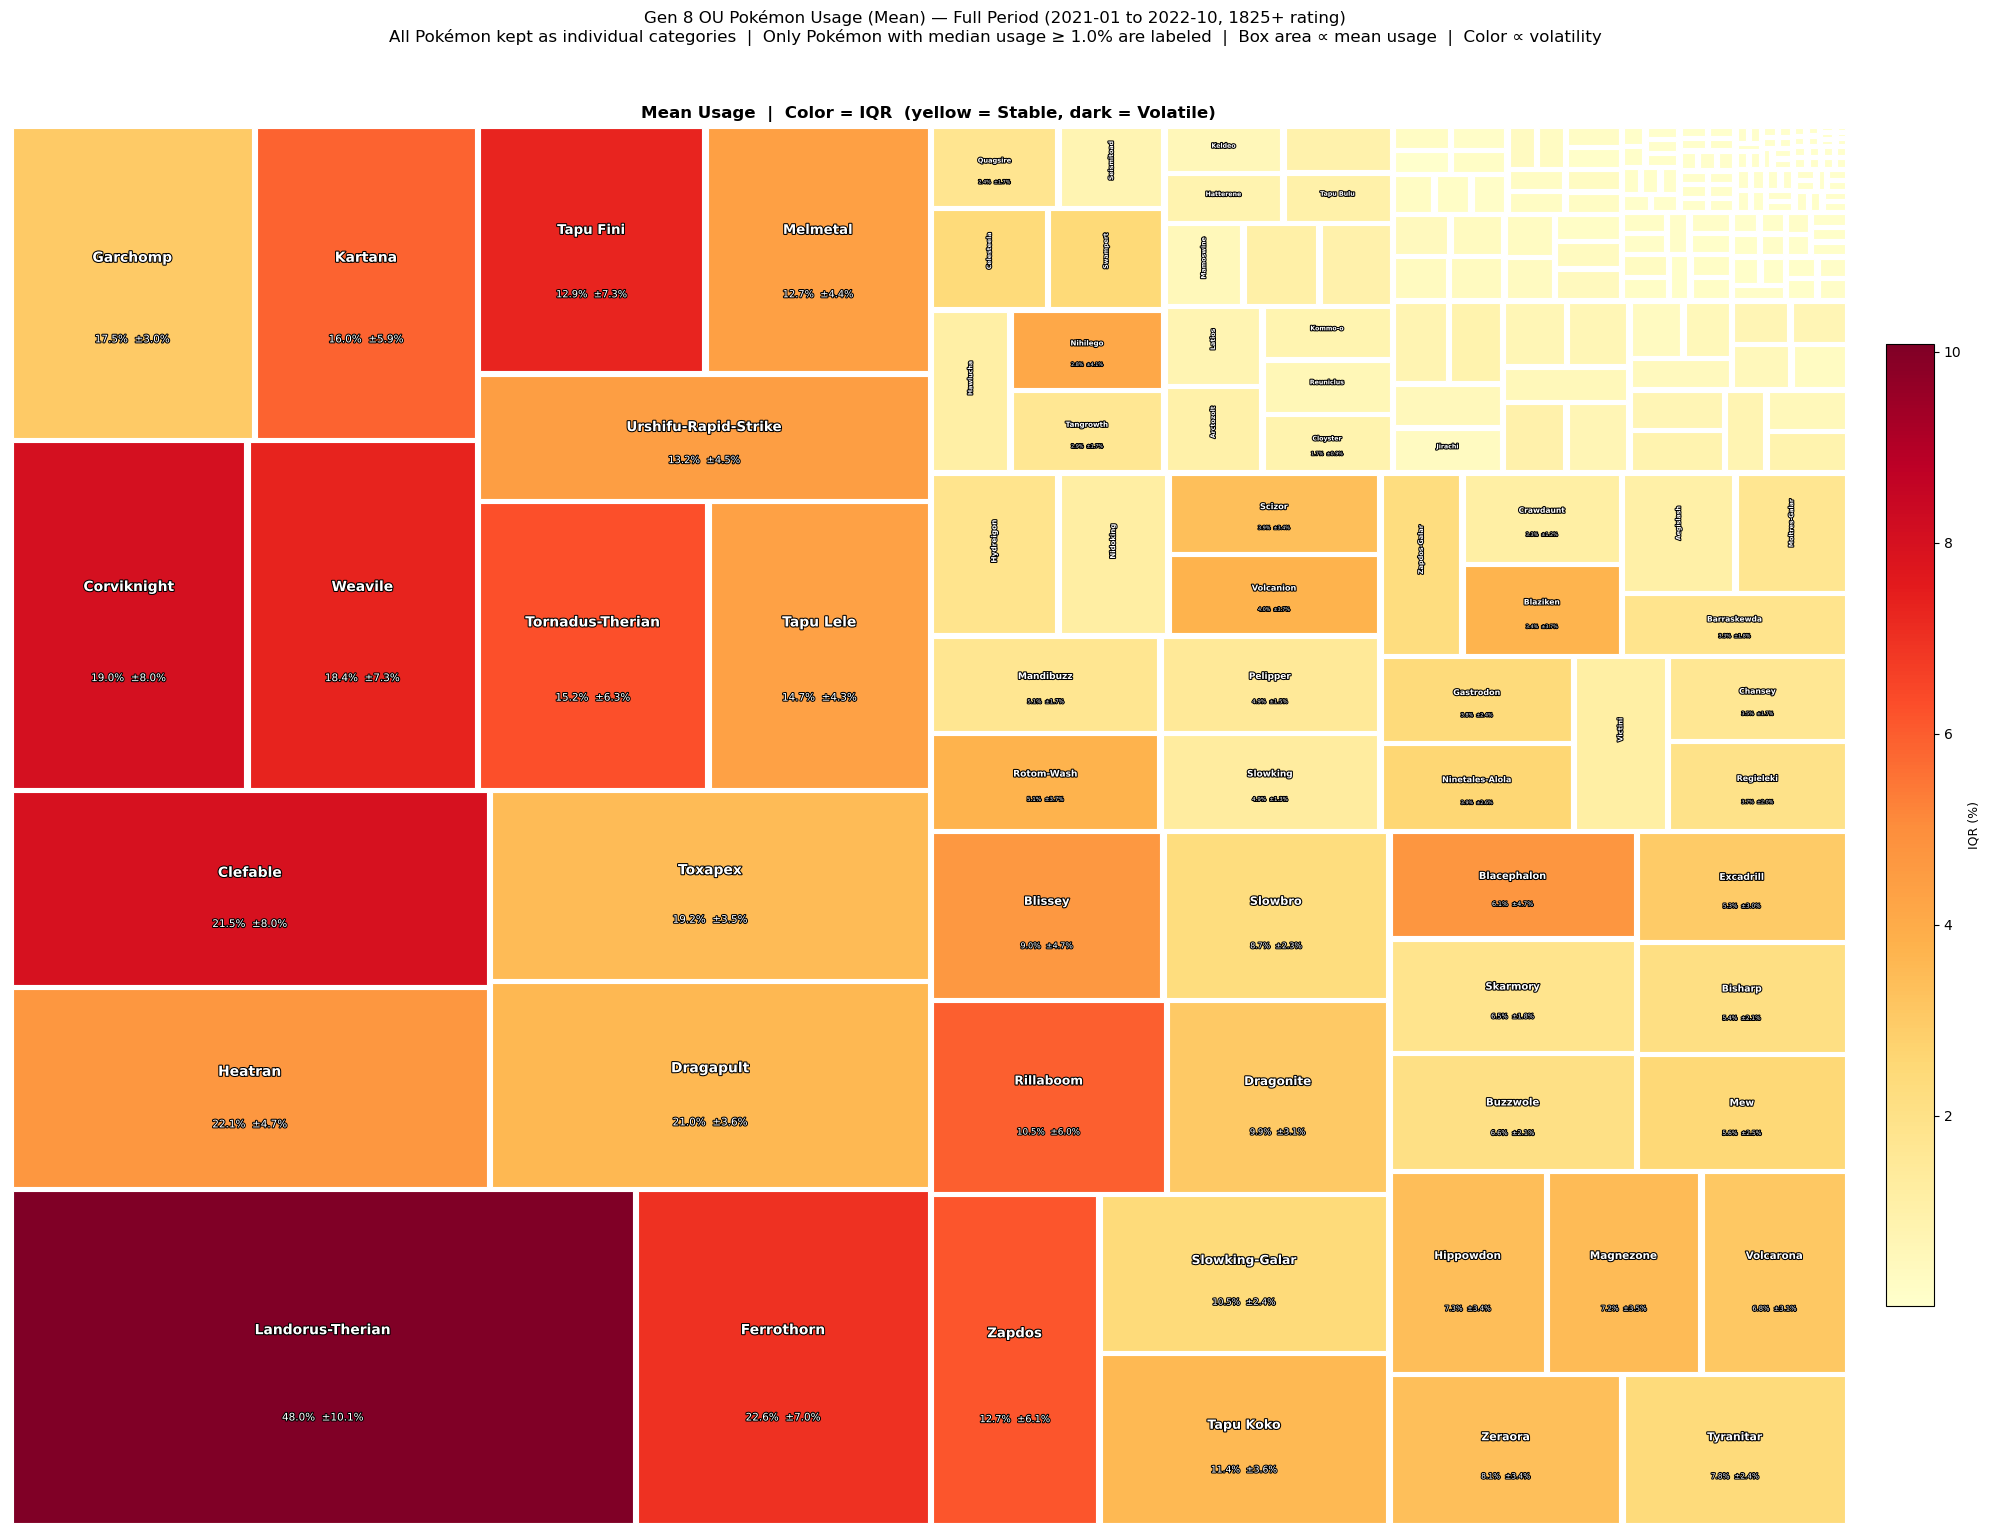

In [38]:
def _tm_layout(sizes, x, y, w, h):
    sizes = [float(s) for s in sizes if s > 0]

    def recurse(vals, x, y, w, h):
        n = len(vals)
        if n == 0:
            return []
        if n == 1:
            return [(x, y, w, h)]
        if n == 2:
            s0, s1 = vals
            total = s0 + s1
            if w >= h:
                w0 = w * (s0 / total)
                return [
                    (x, y, w0, h),
                    (x + w0, y, w - w0, h),
                ]
            else:
                h0 = h * (s0 / total)
                return [
                    (x, y, w, h0),
                    (x, y + h0, w, h - h0),
                ]

        total = sum(vals)
        half = total / 2

        running = 0
        split_idx = 0
        best_diff = float("inf")
        for i, v in enumerate(vals[:-1], start=1):
            running += v
            diff = abs(half - running)
            if diff < best_diff:
                best_diff = diff
                split_idx = i

        left = vals[:split_idx]
        right = vals[split_idx:]
        left_sum = sum(left)

        if w >= h:
            w_left = w * (left_sum / total)
            return (
                recurse(left, x, y, w_left, h) +
                recurse(right, x + w_left, y, w - w_left, h)
            )
        else:
            h_top = h * (left_sum / total)
            return (
                recurse(left, x, y, w, h_top) +
                recurse(right, x, y + h_top, w, h - h_top)
            )

    return recurse(sizes, x, y, w, h)


def _tm_draw(ax, sizes_raw, labels, uncertainty_raw, title, unc_label):
    sizes = np.array(sizes_raw, dtype=float)
    uncertainty = np.array(uncertainty_raw, dtype=float)
    other_mask = np.isnan(uncertainty)
    valid_unc = uncertainty[~other_mask]
    vmin, vmax = valid_unc.min(), valid_unc.max()

    normed = np.where(
        other_mask,
        np.nan,
        (uncertainty - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(uncertainty)
    )

    cmap = cm.get_cmap("YlOrRd")
    colors = ["#aaaaaa" if m else cmap(v) for v, m in zip(normed, other_mask)]

    order = np.argsort(sizes)[::-1]
    sizes_s = sizes[order].tolist()
    labels_s = [labels[i] for i in order]
    colors_s = [colors[i] for i in order]
    unc_s = uncertainty[order]
    mask_s = other_mask[order]
    sizes_a = np.array(sizes_s)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")

    rects = _tm_layout(sizes_s, 0, 0, 100, 100)

    for i, ((rx, ry, rdx, rdy), label, color, unc, is_other) in enumerate(
        zip(rects, labels_s, colors_s, unc_s, mask_s)
    ):
        ax.add_patch(mpatches.FancyBboxPatch(
            (rx + 0.15, ry + 0.15),
            rdx - 0.3,
            rdy - 0.3,
            boxstyle="square,pad=0",
            facecolor=color,
            edgecolor="white",
            linewidth=0.8
        ))

        if rdx < 4 or rdy < 3 or label == "":
            continue

        rotate_label = (rdx < 7 and rdy > rdx)

        fs = max(4.5, min(10, (rdx * rdy) ** 0.42))
        if rotate_label:
            fs = max(4.5, min(9, (rdx * rdy) ** 0.38))

        stroke = [pe.withStroke(linewidth=1.5, foreground="black")]

        ax.text(
            rx + rdx / 2,
            ry + rdy * 0.58,
            label,
            ha="center",
            va="center",
            fontsize=fs,
            fontweight="bold",
            color="white",
            path_effects=stroke,
            clip_on=True,
            rotation=90 if rotate_label else 0,
            rotation_mode="anchor"
        )

        if not is_other and rdx > 6 and rdy > 4 and not rotate_label:
            unc_str = f"±{unc:.1f}%" if not np.isnan(unc) else ""
            ax.text(
                rx + rdx / 2,
                ry + rdy * 0.32,
                f"{sizes_a[i]:.1f}%  {unc_str}",
                ha="center",
                va="center",
                fontsize=max(3.5, fs - 2.5),
                color="white",
                path_effects=stroke,
                clip_on=True
            )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=6)

    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.7).set_label(unc_label, fontsize=9)


tm_plot_all = tm_full[tm_full["pokemon"].isin(tm_legal)].copy()

sizes_all = tm_plot_all["mean_pct"].clip(lower=0.01).tolist()
unc_all = tm_plot_all["iqr"].tolist()
labels_all = [
    name if med >= tm_MIN_USAGE else ""
    for name, med in zip(tm_plot_all["pokemon"], tm_plot_all["med_percent"])
]

tm_fig2, tm_ax2 = plt.subplots(figsize=(20, 15))
_tm_draw(
    ax=tm_ax2,
    sizes_raw=sizes_all,
    labels=labels_all,
    uncertainty_raw=unc_all,
    title="Mean Usage  |  Color = IQR  (yellow = Stable, dark = Volatile)",
    unc_label="IQR (%)",
)
tm_fig2.suptitle(
    "Gen 8 OU Pokémon Usage (Mean) — Full Period (2021-01 to 2022-10, 1825+ rating)\n"
    f"All Pokémon kept as individual categories  |  "
    f"Only Pokémon with median usage ≥ {tm_MIN_USAGE}% are labeled  |  "
    "Box area ∝ mean usage  |  Color ∝ volatility",
    fontsize=12,
    y=1.02
)
tm_fig2.tight_layout()
tm_fig2.savefig(SAVE_DIR / "MeanTREE.png", dpi=150, bbox_inches="tight")
plt.show()

Mean Line -> Bar Graph


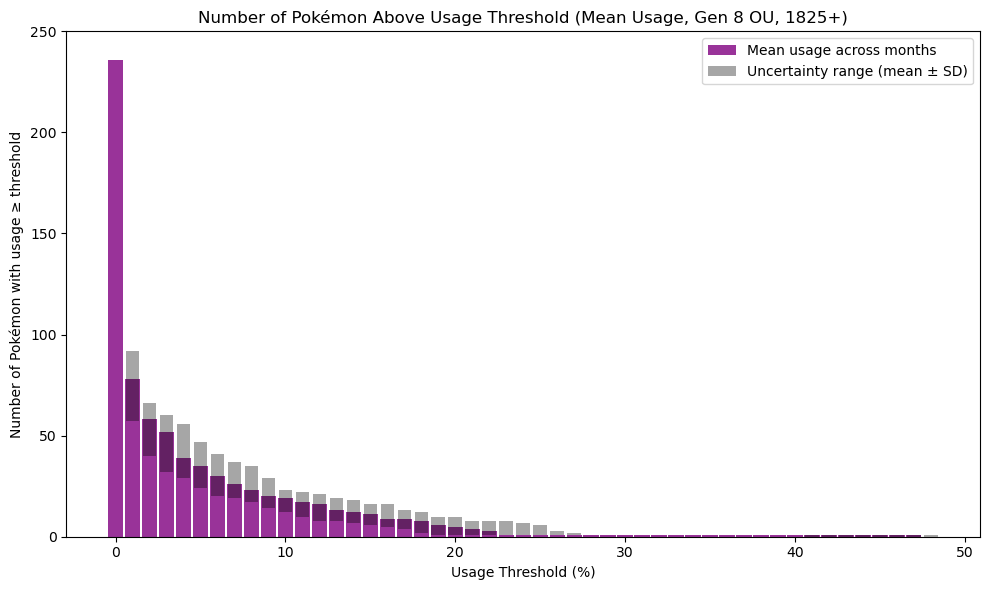

In [24]:
# --- Threshold-count plot based on MEAN usage across months, with transparent bar uncertainty ---

thresholds = np.arange(0, plot_df["mean_percent"].max() + 1, 1)

# Main bar heights: number of Pokémon whose MEAN usage is at least each threshold
counts_mean = np.array([
    (plot_df["mean_percent"] >= t).sum()
    for t in thresholds
])

# Uncertainty bounds from mean ± SD
counts_low = np.array([
    ((plot_df["mean_percent"] - plot_df["sd_percent"]).clip(lower=0) >= t).sum()
    for t in thresholds
])

counts_high = np.array([
    ((plot_df["mean_percent"] + plot_df["sd_percent"]) >= t).sum()
    for t in thresholds
])

# Height of the uncertainty overlay
unc_height = counts_high - counts_low

plt.figure(figsize=(10, 6))

# Main bars
plt.bar(
    thresholds,
    counts_mean,
    width=.9,
    color="purple",
    alpha=0.8,
    label="Mean usage across months",
    zorder=2
)

# Transparent uncertainty bars spanning from low to high
plt.bar(
    thresholds,
    unc_height,
    bottom=counts_low,
    width=0.8,
    color="black",
    alpha=0.35,
    label="Uncertainty range (mean ± SD)",
    zorder=3
)
plt.ylim(0, 250)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Mean Usage, Gen 8 OU, 1825+)")
plt.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / "Line2BarMean.png", dpi=150)
plt.show()